# Nomadic Intelligence — §4.10 Recurrent Gate + Oracle Baseline (v2)

**목적**: Nomadic Full의 성능이 "temporal structure가 있으면 충분"한 것인지,
아니면 explicit transition dynamics control이 필요한지를 검증.

| 모델 | 설명 | 파라미터 |
|---|---|---|
| Standard MoE | input-conditioned gate, no temporal structure | 17,798 |
| **GRU MoE** | GRU gate (implicit temporal learning, no Δx) | 26,502 |
| **Nomadic Full** | explicit Δx + dwell + PolicyNet | 23,053 |
| **Oracle** | regime-specialist MLPs, label-conditioned hard routing (true upper bound) | 3×4,417 |

**핵심 가설**:
- GRU MoE가 Nomadic Full에 미치지 못하면 → implicit temporal structure로는 부족, explicit design 필요
- Nomadic Full이 Oracle에 근접하면 → homeomorphic fixation 주장의 실질적 근거

**수정 사항 (v2)**:
- GRU: train/test 시퀀스를 다른 seed로 생성 + regime 순서 shuffle + Dropout(p=0.15)
- Oracle: Nomadic expert 재사용 → 각 regime 전용 MLP 독립 학습 (true upper bound)

**비교 기준값 (§4.1)**:

| Model | Seq MSE | ΔH | Stable Ent |
|---|---|---|---|
| Standard MoE | 0.410 | 0.017 | 0.952 |
| Nomadic Full | 0.165 | 0.781 | 0.091 |

**Seeds**: 42, 123, 456 | **Epochs**: 220 | **GPU**: L4


In [ ]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA L4
VRAM: 23.7 GB


In [ ]:
import os, random, math
from collections import deque
from dataclasses import dataclass
from typing import Dict, List, Optional
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

matplotlib.rcParams['figure.dpi'] = 120

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEEDS  = [42, 123, 456]

@dataclass
class Config:
    seed: int = 42; device: str = DEVICE
    input_dim: int = 2; output_dim: int = 1; overlap_std: float = 0.9
    hidden_dim: int = 64; num_experts: int = 3; gate_hidden_dim: int = 64
    temperature: float = 0.60
    epochs: int = 220; lr: float = 2e-3; weight_decay: float = 1e-5
    phase_batch_size: int = 64; phase_train_cycles: int = 40
    phase_test_cycles: int = 12; transition_steps: int = 8
    ema_decay: float = 0.80; err_baseline_momentum: float = 0.85
    w_env: float = 1.0; w_err: float = 2.0
    alpha_dogma: float = 0.04; beta_nomad: float = 0.05; beta_phi: float = 0.02
    gamma_diversity: float = 0.08; lambda_sep: float = 0.08
    lambda_cons: float = 0.03; lambda_load: float = 0.03
    tau_k_min: int = 3; tau_k_penalty: float = 0.05
    use_dynamic_tau: bool = True; tau_min: float = 2.0; tau_max: float = 8.0
    tau_var_scale: float = 6.0; tau_var_window: int = 8
    phi_scale_env: float = 1.0; phi_scale_err: float = 1.5
    phi_scale_explain: float = 1.5; phi_scale_gap: float = 0.8
    temp_stable: float = 0.35; temp_transition: float = 0.90
    use_hard_switch: bool = True; phi_hard_threshold: float = 0.30
    policy_hidden_dim: int = 64; policy_mix_weight: float = 0.25
    policy_weight_stay: float = 0.20; policy_weight_target: float = 0.20
    policy_weight_mode: float = 0.10; policy_switch_threshold: float = 0.50

def count_params(m): return sum(p.numel() for p in m.parameters())
print(f'Device: {DEVICE}')


Device: cuda


In [ ]:
REGIME_TO_ID = {'A':0,'B':1,'C':2}
ID_TO_REGIME = {0:'A',1:'B',2:'C'}
REGIME_ORDER = ['A','B','C']

def sample_regime_x(regime, n, cfg):
    centers = {'A':(2.5,2.5),'B':(-2.5,-2.5),'C':(2.5,-2.5)}
    c = torch.tensor(centers[regime], device=cfg.device)
    return cfg.overlap_std * torch.randn(n, 2, device=cfg.device) + c

def regime_function(x, regime):
    x1, x2 = x[:,0], x[:,1]
    if regime=='A':   y = x1 + x2
    elif regime=='B': y = x1 - x2
    elif regime=='C': y = -x1 + 0.5*x2
    return y.unsqueeze(-1)

def generate_phase_sequence(cfg, cycles, shuffle_regimes=False, rng_seed=None):
    xs,ys,rs,tags = [],[],[],[]
    rng = np.random.RandomState(rng_seed) if rng_seed is not None else np.random.RandomState()
    for cyc in range(cycles):
        order = rng.permutation(REGIME_ORDER).tolist() if shuffle_regimes else REGIME_ORDER
        for i, curr_r in enumerate(order):
            next_r = order[(i+1)%3]
            x_s = sample_regime_x(curr_r, cfg.phase_batch_size, cfg)
            xs.append(x_s); ys.append(regime_function(x_s,curr_r))
            rs.append(torch.full((cfg.phase_batch_size,),REGIME_TO_ID[curr_r],dtype=torch.long,device=cfg.device))
            tags.extend([f'stable_{curr_r}']*cfg.phase_batch_size)
            for step in range(cfg.transition_steps):
                alpha = (step+1)/cfg.transition_steps
                xa = sample_regime_x(curr_r,cfg.phase_batch_size,cfg)
                xb = sample_regime_x(next_r,cfg.phase_batch_size,cfg)
                xm = (1-alpha)*xa + alpha*xb
                ym = (1-alpha)*regime_function(xm,curr_r) + alpha*regime_function(xm,next_r)
                dom = curr_r if alpha<0.5 else next_r
                xs.append(xm); ys.append(ym)
                rs.append(torch.full((cfg.phase_batch_size,),REGIME_TO_ID[dom],dtype=torch.long,device=cfg.device))
                tags.extend([f'transition_{curr_r}_to_{next_r}']*cfg.phase_batch_size)
    return torch.cat(xs),torch.cat(ys),torch.cat(rs),tags

def iterate_minibatches(X,Y,R,bs):
    n=X.size(0)
    for s in range(0,n,bs): yield X[s:min(s+bs,n)],Y[s:min(s+bs,n)],R[s:min(s+bs,n)]

print('Data utilities ready.')


Data utilities ready.


In [ ]:
# ============================================================
# Model Definitions
# ============================================================

class Expert(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim,hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim,hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim,output_dim),
        )
    def forward(self,x): return self.net(x)


class StandardMoE(nn.Module):
    """Stateless input-conditioned gating — §4.1 baseline."""
    def __init__(self, input_dim, hidden_dim, output_dim, num_experts, gate_hidden):
        super().__init__()
        self.num_experts = num_experts
        self.experts = nn.ModuleList([Expert(input_dim,hidden_dim,output_dim) for _ in range(num_experts)])
        self.gate = nn.Sequential(
            nn.Linear(input_dim,gate_hidden), nn.ReLU(),
            nn.Linear(gate_hidden,gate_hidden), nn.ReLU(),
            nn.Linear(gate_hidden,num_experts),
        )
    def forward(self, x, hard=False):
        gp = F.softmax(self.gate(x), dim=-1)
        eo = torch.stack([e(x) for e in self.experts], dim=1)
        r  = F.one_hot(gp.argmax(-1),self.num_experts).float() if hard else gp
        return (r.unsqueeze(-1)*eo).sum(1), gp, eo


class GRUMoE(nn.Module):
    """
    GRU-gated MoE (Option A): GRU replaces GateNet entirely.
    Input: x only (no Δx). Hidden state carries temporal context implicitly.
    Per-batch: h_t = GRU(x_mean_t, h_{t-1}), gate = softmax(Linear(h_t))
    Params: 26,502 (> Nomadic Full 23,053)
    """
    def __init__(self, input_dim, hidden_dim, output_dim, num_experts, dropout=0.15):
        super().__init__()
        self.num_experts = num_experts
        self.hidden_dim  = hidden_dim
        self.experts     = nn.ModuleList([Expert(input_dim,hidden_dim,output_dim) for _ in range(num_experts)])
        self.gru         = nn.GRUCell(input_dim, hidden_dim)
        self.gate_head   = nn.Linear(hidden_dim, num_experts)
        self.dropout     = nn.Dropout(p=dropout)  # regularize hidden state

    def forward(self, x, h, temperature=1.0, hard=False):
        """
        x: [B, input_dim]
        h: [1, hidden_dim]  — batch-level hidden state (batch mean fed to GRU)
        Returns: y_hat, gate_probs, expert_outputs, h_new
        """
        x_mean = x.mean(0, keepdim=True)           # [1, d] — batch summary
        h_new  = self.gru(x_mean, h)               # [1, hidden_dim]
        h_drop = self.dropout(h_new) if self.training else h_new  # dropout during train only
        logits = self.gate_head(h_drop)            # [1, K]
        gp_batch = F.softmax(logits / temperature, dim=-1)
        gp = gp_batch.expand(x.size(0), -1)     # [B, K] — broadcast to batch
        eo = torch.stack([e(x) for e in self.experts], dim=1)  # [B,K,1]
        r  = F.one_hot(gp.argmax(-1),self.num_experts).float() if hard else gp
        return (r.unsqueeze(-1)*eo).sum(1), gp, eo, h_new  # always return raw h_new (no dropout)

    def init_hidden(self, device):
        return torch.zeros(1, self.hidden_dim, device=device)


class NomadicMoE(nn.Module):
    """Nomadic Full — identical to task_generalization.ipynb."""
    def __init__(self, input_dim, hidden_dim, output_dim, num_experts,
                 gate_hidden_dim, policy_hidden_dim=64):
        super().__init__()
        self.num_experts = num_experts
        self.experts = nn.ModuleList([Expert(input_dim,hidden_dim,output_dim) for _ in range(num_experts)])
        self.gate = nn.Sequential(
            nn.Linear(input_dim+2,gate_hidden_dim), nn.ReLU(),
            nn.Linear(gate_hidden_dim,gate_hidden_dim), nn.ReLU(),
            nn.Linear(gate_hidden_dim,num_experts),
        )
        self.policy_shared = nn.Sequential(
            nn.Linear(input_dim+5,policy_hidden_dim), nn.ReLU(),
            nn.Linear(policy_hidden_dim,policy_hidden_dim), nn.ReLU(),
        )
        self.stay_head   = nn.Linear(policy_hidden_dim,2)
        self.target_head = nn.Linear(policy_hidden_dim,num_experts)
        self.mode_head   = nn.Linear(policy_hidden_dim,2)

    def gate_forward(self, x, dh, de, temperature):
        return F.softmax(self.gate(torch.cat([x,dh,de],dim=-1)) / temperature, dim=-1)

    def policy_forward(self, pi):
        h = self.policy_shared(pi)
        return (F.softmax(self.stay_head(h),dim=-1),
                F.softmax(self.target_head(h),dim=-1),
                F.softmax(self.mode_head(h),dim=-1))

    def forward(self, x, dh, de, temperature, hard=False):
        gp = self.gate_forward(x,dh,de,temperature)
        eo = torch.stack([e(x) for e in self.experts], dim=1)
        r  = F.one_hot(gp.argmax(-1),self.num_experts).float() if hard else gp
        return (r.unsqueeze(-1)*eo).sum(1), gp, eo


# ── 파라미터 수 확인
cfg_tmp = Config()
sm  = StandardMoE(2,64,1,3,64)
gm  = GRUMoE(2,64,1,3,dropout=0.15)
nm  = NomadicMoE(2,64,1,3,64,64)
print(f'Standard MoE:  {count_params(sm):,}')
print(f'GRU MoE:       {count_params(gm):,}  (GRU gate has more params than PolicyNet)')
print(f'Nomadic Full:  {count_params(nm):,}')
print('\nNote: GRU MoE has MORE parameters than Nomadic Full.')
print('If GRU MoE still underperforms, capacity is not the explanation.')


Standard MoE:  17,798
GRU MoE:       26,502  (GRU gate has more params than PolicyNet)
Nomadic Full:  23,053

Note: GRU MoE has MORE parameters than Nomadic Full.
If GRU MoE still underperforms, capacity is not the explanation.


In [ ]:
class HybridDeltaTracker:
    def __init__(self,cfg):
        self.cfg=cfg; self.prev_x_mean=None; self.err_ema=None
        self.err_baseline=None; self.recent_de=deque(maxlen=cfg.tau_var_window)
    def reset(self):
        self.prev_x_mean=None; self.err_ema=None
        self.err_baseline=None; self.recent_de.clear()
    def compute_dynamic_tau(self,s2):
        return float(np.clip(self.cfg.tau_min+(self.cfg.tau_max-self.cfg.tau_min)/(1+self.cfg.tau_var_scale*s2),
                             self.cfg.tau_min,self.cfg.tau_max))
    def compute(self,x,mse):
        xm=x.mean(0,keepdim=True)
        de=0.0 if self.prev_x_mean is None else float(torch.norm(xm-self.prev_x_mean,p=2).item())
        be=mse.detach()
        if self.err_ema is None:
            self.err_ema=be; self.err_baseline=be; derr=0.0
        else:
            self.err_ema=self.cfg.ema_decay*self.err_ema+(1-self.cfg.ema_decay)*be
            self.err_baseline=self.cfg.err_baseline_momentum*self.err_baseline+(1-self.cfg.err_baseline_momentum)*self.err_ema
            derr=float(torch.relu(self.err_ema-self.err_baseline).item())
        dh=float(torch.tanh(torch.tensor(self.cfg.w_env*de+self.cfg.w_err*derr)).item())
        self.prev_x_mean=xm.detach()
        self.recent_de.append(de)
        s2=float(np.var(self.recent_de)) if len(self.recent_de)>=2 else 0.0
        return torch.full((x.size(0),1),dh,device=self.cfg.device),de,derr,dh,s2,self.compute_dynamic_tau(s2)

class DwellTimeRegularizer:
    def __init__(self,cfg): self.cfg=cfg; self.cur=None; self.cnt=0
    def reset(self): self.cur=None; self.cnt=0
    def compute(self,gp,tau=None):
        dom=int(torch.bincount(gp.argmax(-1),minlength=gp.size(-1)).argmax().item())
        if dom==self.cur: self.cnt+=1
        else: self.cur=dom; self.cnt=1
        eps=1e-8; ent=-(gp*(gp+eps).log()).sum(-1).mean()
        tc=float(tau if tau is not None else self.cfg.tau_k_min)
        if self.cnt<=tc: return -self.cfg.tau_k_penalty*ent
        else: return min((self.cnt-tc)*self.cfg.tau_k_penalty,self.cfg.tau_k_penalty*10)*ent

def gate_entropy(gp):
    eps=1e-8; return -(gp*(gp+eps).log()).sum(-1)

def compute_load_balancing_loss(gp):
    K=gp.size(-1); mg=gp.mean(0); top1=gp.argmax(-1)
    return K*(torch.bincount(top1,minlength=K).float()/top1.size(0)*mg).sum()

def compute_diversity_loss(eo):
    K=eo.size(1)
    if K<2: return eo.new_zeros(1).squeeze()
    ii,jj=zip(*[(i,j) for i in range(K) for j in range(i+1,K)])
    return F.cosine_similarity(eo[:,ii,:],eo[:,jj,:],dim=-1).mean()

def compute_explanation_signals(yt,yh,eo,gp):
    expl=F.mse_loss(yh,yt)
    pe=((eo-yt.unsqueeze(1))**2).mean(-1)
    t1=pe.gather(1,gp.argmax(-1).unsqueeze(1)).mean()
    return expl,torch.relu(t1-pe.min(1).values.mean())

def compute_phi(de,derr,expl,gap,cfg):
    d=expl.device
    return torch.tanh(cfg.phi_scale_env*torch.tensor(de,device=d)+cfg.phi_scale_err*torch.tensor(derr,device=d)
                      +cfg.phi_scale_explain*expl.detach()+cfg.phi_scale_gap*gap.detach())

def compute_temp(phi,cfg):
    return cfg.temp_stable+(cfg.temp_transition-cfg.temp_stable)*float(phi.mean().item())

def build_policy_input(xb,dh_t,de_t,phi,s2,dtau):
    xs=xb.mean(0,keepdim=True).expand(xb.size(0),-1)
    pt=torch.full((xb.size(0),1),float(phi.mean().item()),device=xb.device)
    s2t=torch.full((xb.size(0),1),float(np.tanh(s2*10)),device=xb.device)
    tt=torch.full((xb.size(0),1),float(np.tanh((dtau-5)/5)),device=xb.device)
    return torch.cat([xs,dh_t,de_t,pt,s2t,tt],dim=-1)

def build_policy_targets(yb,eo,phi,s2,dtau,cfg):
    pe=((eo-yb.unsqueeze(1))**2).mean(-1)
    tgt=pe.mean(0).argmin().long()
    pv=float(phi.mean().item())
    sw=1 if(pv>cfg.policy_switch_threshold or s2>0.05) else 0
    mod=1 if(pv<=cfg.policy_switch_threshold and dtau>=5.5) else 0
    return sw,tgt,mod

def compute_regime_gate_stats(gp,rb):
    dev=gp.device; vm=[]; lc=torch.tensor(0.,device=dev); cnt=0
    for rid in range(3):
        mask=rb==rid
        if mask.sum()==0: continue
        gr=gp[mask]; ur=gr.mean(0); vm.append(ur)
        lc=lc+((gr-ur.unsqueeze(0))**2).sum(-1).mean(); cnt+=1
    if cnt>0: lc=lc/cnt
    if len(vm)<2: return torch.tensor(0.,device=dev),lc
    pw=[torch.norm(vm[i]-vm[j],p=2) for i in range(len(vm)) for j in range(i+1,len(vm))]
    return -torch.stack(pw).mean(),lc

def regimewise_usage(gp,rb,K):
    top1=gp.argmax(-1); usage={}
    for rid in range(3):
        mask=rb==rid; name=ID_TO_REGIME[rid]
        if mask.sum()==0: usage[name]=np.zeros(K); continue
        c=torch.bincount(top1[mask],minlength=K).float()
        usage[name]=(c/c.sum().clamp_min(1)).cpu().numpy()
    return usage

def infer_r2e(usage): return {r:int(np.argmax(usage[r])) for r in ['A','B','C']}

def compute_switch_latency(reg_seq,top1_seq,r2e):
    lats=[]; prev=reg_seq[0] if reg_seq else None
    for t in range(1,len(reg_seq)):
        curr=reg_seq[t]
        if curr!=prev:
            tgt=r2e.get(curr)
            if tgt is not None:
                for k in range(t,len(top1_seq)):
                    if int(top1_seq[k])==int(tgt): lats.append(k-t); break
        prev=curr
    return lats

print('Utilities ready.')


Utilities ready.


In [ ]:
def eval_stdmoe(model,X,Y,R,phase_tags,cfg):
    model.eval(); all_y,all_g,tags,ents=[],[],[],[]
    with torch.no_grad():
        for bi,(xb,yb,rb) in enumerate(iterate_minibatches(X,Y,R,cfg.phase_batch_size)):
            yh,gp,_=model(xb); all_y.append(yh); all_g.append(gp)
            tags.append(phase_tags[bi*cfg.phase_batch_size])
            ents.append(gate_entropy(gp).mean().item())
    seq_mse=F.mse_loss(torch.cat(all_y),Y).item()
    sh=[e for t,e in zip(tags,ents) if t.startswith('stable_')]
    th=[e for t,e in zip(tags,ents) if t.startswith('transition_')]
    return seq_mse,{'sh':float(np.mean(sh)) if sh else float('nan'),
                    'th':float(np.mean(th)) if th else float('nan'),
                    'dh':float(np.mean(th)-np.mean(sh)) if(sh and th) else float('nan')}


def eval_gru(model,X,Y,R,phase_tags,cfg):
    model.eval(); h=model.init_hidden(cfg.device)
    all_y,all_g,tags,ents,top1s,regs=[],[],[],[],[],[]
    with torch.no_grad():
        for bi,(xb,yb,rb) in enumerate(iterate_minibatches(X,Y,R,cfg.phase_batch_size)):
            yh,gp,_,h=model(xb,h,cfg.temperature)
            all_y.append(yh); all_g.append(gp)
            tags.append(phase_tags[bi*cfg.phase_batch_size])
            ents.append(gate_entropy(gp).mean().item())
            top1s.append(int(torch.bincount(gp.argmax(-1),minlength=cfg.num_experts).argmax().item()))
            regs.append(ID_TO_REGIME[int(rb[0].item())])
    seq_mse=F.mse_loss(torch.cat(all_y),Y).item()
    G=torch.cat(all_g); usage=regimewise_usage(G,R,cfg.num_experts)
    r2e=infer_r2e(usage)
    lats=compute_switch_latency(regs,np.array(top1s),r2e)
    sh=[e for t,e in zip(tags,ents) if t.startswith('stable_')]
    th=[e for t,e in zip(tags,ents) if t.startswith('transition_')]
    return seq_mse,{'sh':float(np.mean(sh)) if sh else float('nan'),
                    'th':float(np.mean(th)) if th else float('nan'),
                    'dh':float(np.mean(th)-np.mean(sh)) if(sh and th) else float('nan'),
                    'lat':float(np.mean(lats)) if lats else float('nan')}


def eval_nomadic(model,X,Y,R,phase_tags,cfg):
    model.eval(); tracker=HybridDeltaTracker(cfg); tracker.reset()
    all_y,all_g,tags,ents,top1s,regs=[],[],[],[],[],[]
    with torch.no_grad():
        for bi,(xb,yb,rb) in enumerate(iterate_minibatches(X,Y,R,cfg.phase_batch_size)):
            z=torch.zeros((xb.size(0),1),device=cfg.device)
            wm=F.mse_loss(model(xb,z,z,cfg.temperature)[0],yb)
            dh_t,de,derr,dh,s2,dtau=tracker.compute(xb,wm)
            de_t=torch.full((xb.size(0),1),derr,device=cfg.device)
            py,pg,pe=model(xb,dh_t,de_t,cfg.temperature)
            expl,gap=compute_explanation_signals(yb,py,pe,pg)
            phi=compute_phi(de,derr,expl,gap,cfg); temp=compute_temp(phi,cfg)
            yh,gp,eo=model(xb,dh_t,de_t,temp)
            pi=build_policy_input(xb,dh_t,de_t,phi,s2,dtau)
            sw,tp,mp=model.policy_forward(pi)
            em=cfg.policy_mix_weight*float(sw[:,1].mean().item())
            ti=tp.mean(0).argmax()
            toh=(F.one_hot(ti,cfg.num_experts).float().unsqueeze(0).expand(xb.size(0),-1)-gp).detach()+gp
            mx=(1-em)*gp+em*toh
            fs=dh>cfg.phi_hard_threshold
            hm=cfg.use_hard_switch and(mp[:,1].mean().item()>0.5) and not fs
            fr=F.one_hot(mx.argmax(-1),cfg.num_experts).float() if hm else mx
            yh=(fr.unsqueeze(-1)*eo).sum(1); gp=fr
            all_y.append(yh); all_g.append(gp)
            tags.append(phase_tags[bi*cfg.phase_batch_size])
            ents.append(gate_entropy(gp).mean().item())
            top1s.append(int(torch.bincount(gp.argmax(-1),minlength=cfg.num_experts).argmax().item()))
            regs.append(ID_TO_REGIME[int(rb[0].item())])
    seq_mse=F.mse_loss(torch.cat(all_y),Y).item()
    G=torch.cat(all_g); usage=regimewise_usage(G,R,cfg.num_experts)
    r2e=infer_r2e(usage)
    lats=compute_switch_latency(regs,np.array(top1s),r2e)
    sh=[e for t,e in zip(tags,ents) if t.startswith('stable_')]
    th=[e for t,e in zip(tags,ents) if t.startswith('transition_')]
    return seq_mse,{'sh':float(np.mean(sh)) if sh else float('nan'),
                    'th':float(np.mean(th)) if th else float('nan'),
                    'dh':float(np.mean(th)-np.mean(sh)) if(sh and th) else float('nan'),
                    'lat':float(np.mean(lats)) if lats else float('nan')}


def train_oracle_experts(cfg, Xtr, Ytr, Rtr):
    """
    Oracle expert 학습: 각 regime 전용 MLP를 해당 regime 데이터로만 독립 학습.
    - Regime A 데이터만으로 Expert_A 학습
    - Regime B 데이터만으로 Expert_B 학습
    - Regime C 데이터만으로 Expert_C 학습
    이렇게 학습된 expert들은 자신의 regime에서 이론적으로 최적.
    Oracle evaluation에서 phase_tag(regime label)를 직접 참조해서 해당 expert를 선택.
    """
    experts = []
    for rid in range(cfg.num_experts):
        regime_name = ID_TO_REGIME[rid]
        # 해당 regime의 stable 데이터만 추출
        mask = Rtr == rid
        if mask.sum() == 0:
            experts.append(Expert(cfg.input_dim, cfg.hidden_dim, cfg.output_dim).to(cfg.device))
            continue
        Xr = Xtr[mask]; Yr = Ytr[mask]
        e = Expert(cfg.input_dim, cfg.hidden_dim, cfg.output_dim).to(cfg.device)
        opt = torch.optim.Adam(e.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
        # regime 전용 데이터를 220 epoch 학습 (Nomadic과 동일 epoch)
        n = Xr.size(0)
        for ep in range(cfg.epochs):
            e.train()
            perm = torch.randperm(n, device=cfg.device)
            for s in range(0, n, cfg.phase_batch_size):
                idx = perm[s:min(s+cfg.phase_batch_size, n)]
                opt.zero_grad()
                F.mse_loss(e(Xr[idx]), Yr[idx]).backward()
                opt.step()
        e.eval()
        with torch.no_grad():
            train_mse = F.mse_loss(e(Xr), Yr).item()
        print(f'  [Oracle Expert_{regime_name}] Train MSE on regime {regime_name}: {train_mse:.4f}')
        experts.append(e)
    return experts


def eval_oracle(experts, X, Y, R, phase_tags, cfg):
    """
    Oracle: regime label을 직접 참조하여 해당 regime 전용 expert로 hard routing.
    phase_tags의 dominant regime을 보고 stable_A → Expert_A, stable_B → Expert_B 등으로 라우팅.
    transition 구간에서는 dominant regime(alpha<0.5이면 curr, 아니면 next)의 expert 사용.
    이것이 진정한 upper bound: 같은 expert capacity에서 label을 알고 있을 때의 성능.
    """
    [e.eval() for e in experts]
    all_y, tags, ents, top1s, regs = [], [], [], [], []
    with torch.no_grad():
        for bi, (xb, yb, rb) in enumerate(iterate_minibatches(X, Y, R, cfg.phase_batch_size)):
            # dominant regime from phase_tag (label 직접 참조)
            tag = phase_tags[bi * cfg.phase_batch_size]
            # stable_A → 0, transition_A_to_B에서 dominant은 rb[0]
            dom_regime = int(rb[0].item())   # REGIME_TO_ID 기준
            yh = experts[dom_regime](xb)
            K = len(experts)
            gp = F.one_hot(torch.full((xb.size(0),), dom_regime,
                                       dtype=torch.long, device=cfg.device), K).float()
            all_y.append(yh)
            tags.append(tag)
            ents.append(0.0)  # hard routing: entropy = 0
            top1s.append(dom_regime)
            regs.append(ID_TO_REGIME[dom_regime])
    seq_mse = F.mse_loss(torch.cat(all_y), Y).item()
    r2e = {r: i for i, r in enumerate(['A', 'B', 'C'])}
    lats = compute_switch_latency(regs, np.array(top1s), r2e)
    sh = [e for t, e in zip(tags, ents) if t.startswith('stable_')]
    th = [e for t, e in zip(tags, ents) if t.startswith('transition_')]
    return seq_mse, {'sh': 0.0, 'th': 0.0, 'dh': 0.0,
                     'lat': float(np.mean(lats)) if lats else float('nan')}

print('Evaluation functions ready.')


Evaluation functions ready.


In [ ]:
def train_stdmoe(cfg,Xtr,Ytr,Rtr,Xte,Yte,Rte,tags_te):
    m=StandardMoE(cfg.input_dim,cfg.hidden_dim,cfg.output_dim,cfg.num_experts,cfg.gate_hidden_dim).to(cfg.device)
    opt=torch.optim.Adam(m.parameters(),lr=cfg.lr,weight_decay=cfg.weight_decay)
    mse_log,dyn_log=[],[]
    for ep in range(cfg.epochs):
        m.train()
        for xb,yb,_ in iterate_minibatches(Xtr,Ytr,Rtr,cfg.phase_batch_size):
            opt.zero_grad()
            yh,gp,eo=m(xb)
            (F.mse_loss(yh,yb)+cfg.gamma_diversity*compute_diversity_loss(eo)
             +cfg.lambda_load*compute_load_balancing_loss(gp)).backward()
            opt.step()
        mse,dyn=eval_stdmoe(m,Xte,Yte,Rte,tags_te,cfg)
        mse_log.append(mse); dyn_log.append(dyn)
        if(ep+1)%55==0 or ep==0:
            print(f'  [StdMoE] Ep{ep+1:03d} MSE={mse:.4f} ΔH={dyn["dh"]:.3f}')
    return m,mse_log,dyn_log


def train_gru(cfg,Xtr,Ytr,Rtr,Xte,Yte,Rte,tags_te):
    """
    GRU MoE training. h resets at each epoch start (like tracker.reset()).
    Within an epoch, h carries forward across the sequential minibatches.
    This matches the sequential evaluation protocol.
    """
    m=GRUMoE(cfg.input_dim,cfg.hidden_dim,cfg.output_dim,cfg.num_experts,dropout=0.15).to(cfg.device)
    opt=torch.optim.Adam(m.parameters(),lr=cfg.lr,weight_decay=cfg.weight_decay*5)  # 5× weight_decay for GRU
    mse_log,dyn_log=[],[]
    for ep in range(cfg.epochs):
        m.train()
        h=m.init_hidden(cfg.device)
        for xb,yb,rb in iterate_minibatches(Xtr,Ytr,Rtr,cfg.phase_batch_size):
            opt.zero_grad()
            yh,gp,eo,h_new=m(xb,h.detach(),cfg.temperature)  # detach to avoid BPTT across batches
            h=h_new.detach()
            sep_l,cons_l=compute_regime_gate_stats(gp,rb)
            (F.mse_loss(yh,yb)
             +cfg.gamma_diversity*compute_diversity_loss(eo)
             +cfg.lambda_load*compute_load_balancing_loss(gp)
             +cfg.lambda_sep*sep_l
             +cfg.lambda_cons*cons_l).backward()
            opt.step()
        mse,dyn=eval_gru(m,Xte,Yte,Rte,tags_te,cfg)
        mse_log.append(mse); dyn_log.append(dyn)
        if(ep+1)%55==0 or ep==0:
            print(f'  [GRUMoE] Ep{ep+1:03d} MSE={mse:.4f} ΔH={dyn["dh"]:.3f} StH={dyn["sh"]:.3f}')
    return m,mse_log,dyn_log


def train_nomadic(cfg,Xtr,Ytr,Rtr,Xte,Yte,Rte,tags_te):
    m=NomadicMoE(cfg.input_dim,cfg.hidden_dim,cfg.output_dim,cfg.num_experts,
                 cfg.gate_hidden_dim,cfg.policy_hidden_dim).to(cfg.device)
    opt=torch.optim.Adam(m.parameters(),lr=cfg.lr,weight_decay=cfg.weight_decay)
    mse_log,dyn_log=[],[]
    for ep in range(cfg.epochs):
        m.train(); tracker=HybridDeltaTracker(cfg); tracker.reset()
        dwr=DwellTimeRegularizer(cfg); dwr.reset()
        for xb,yb,rb in iterate_minibatches(Xtr,Ytr,Rtr,cfg.phase_batch_size):
            opt.zero_grad()
            z=torch.zeros((xb.size(0),1),device=cfg.device)
            with torch.no_grad(): wm=F.mse_loss(m(xb,z,z,cfg.temperature)[0],yb)
            dh_t,de,derr,dh,s2,dtau=tracker.compute(xb,wm)
            de_t=torch.full((xb.size(0),1),derr,device=cfg.device)
            with torch.no_grad(): py,pg,pe=m(xb,dh_t,de_t,cfg.temperature)
            expl,gap=compute_explanation_signals(yb,py,pe,pg)
            phi=compute_phi(de,derr,expl,gap,cfg); temp=compute_temp(phi,cfg)
            pi=build_policy_input(xb,dh_t,de_t,phi,s2,dtau)
            sw,tp,mp=m.policy_forward(pi)
            yh,gp,eo=m(xb,dh_t,de_t,temp)
            em=cfg.policy_mix_weight*float(sw[:,1].mean().item())
            ti=tp.mean(0).argmax()
            toh=(F.one_hot(ti,cfg.num_experts).float().unsqueeze(0).expand(xb.size(0),-1)-gp).detach()+gp
            mx=(1-em)*gp+em*toh
            fs=dh>cfg.phi_hard_threshold
            hm=cfg.use_hard_switch and(mp[:,1].mean().item()>0.5) and not fs
            fr=F.one_hot(mx.argmax(-1),cfg.num_experts).float() if hm else mx
            yh=(fr.unsqueeze(-1)*eo).sum(1)
            _,gap2=compute_explanation_signals(yb,yh,eo,fr)
            sl,cl=compute_regime_gate_stats(fr,rb)
            td=dtau if cfg.use_dynamic_tau else float(cfg.tau_k_min)
            dw=dwr.compute(fr,tau=td)
            sw_t=torch.full((xb.size(0),),build_policy_targets(yb,pe,phi,s2,dtau,cfg)[0],dtype=torch.long,device=cfg.device)
            tg_t=torch.full((xb.size(0),),int(build_policy_targets(yb,pe,phi,s2,dtau,cfg)[1].item()),dtype=torch.long,device=cfg.device)
            md_t=torch.full((xb.size(0),),build_policy_targets(yb,pe,phi,s2,dtau,cfg)[2],dtype=torch.long,device=cfg.device)
            loss=(F.mse_loss(yh,yb)+cfg.beta_phi*(phi.detach()*gap2)
                  +cfg.alpha_dogma*(gp.mean(0).pow(2).sum()-1/cfg.num_experts)
                  -cfg.beta_nomad*(-(gp*(gp+1e-8).log()).sum(-1).mean())
                  +cfg.gamma_diversity*compute_diversity_loss(eo)
                  +cfg.lambda_sep*sl+cfg.lambda_cons*cl
                  +cfg.lambda_load*compute_load_balancing_loss(fr)
                  +cfg.policy_weight_stay*F.nll_loss(torch.log(sw+1e-8),sw_t)
                  +cfg.policy_weight_target*F.nll_loss(torch.log(tp+1e-8),tg_t)
                  +cfg.policy_weight_mode*F.nll_loss(torch.log(mp+1e-8),md_t)-dw)
            loss.backward(); opt.step()
        mse,dyn=eval_nomadic(m,Xte,Yte,Rte,tags_te,cfg)
        mse_log.append(mse); dyn_log.append(dyn)
        if(ep+1)%55==0 or ep==0:
            print(f'  [Nomadic] Ep{ep+1:03d} MSE={mse:.4f} ΔH={dyn["dh"]:.3f} StH={dyn["sh"]:.3f}')
    return m,mse_log,dyn_log

print('Training functions ready.')


Training functions ready.


In [8]:
import time

all_results = {m:{} for m in ['StdMoE','GRU','Nomadic','Oracle']}

for seed in SEEDS:
    t0=time.time()
    print(f'\n========== Seed {seed} ==========')
    set_seed(seed); cfg=Config(seed=seed)
    # v2: train에 regime 순서 shuffle 적용 (GRU 과적합 방지)
    # test는 고정 순서 유지 (§4.1과 동일 평가 조건)
    Xtr,Ytr,Rtr,tags_tr=generate_phase_sequence(cfg,cfg.phase_train_cycles,
                                                  shuffle_regimes=True, rng_seed=seed)
    Xte,Yte,Rte,tags_te=generate_phase_sequence(cfg,cfg.phase_test_cycles,
                                                  shuffle_regimes=False)

    print('--- Standard MoE ---')
    sm,sm_mse,sm_dyn=train_stdmoe(cfg,Xtr,Ytr,Rtr,Xte,Yte,Rte,tags_te)
    all_results['StdMoE'][seed]={'mse_log':sm_mse,'dyn_log':sm_dyn}

    print('--- GRU MoE ---')
    gm,gm_mse,gm_dyn=train_gru(cfg,Xtr,Ytr,Rtr,Xte,Yte,Rte,tags_te)
    all_results['GRU'][seed]={'mse_log':gm_mse,'dyn_log':gm_dyn}

    print('--- Nomadic Full ---')
    nm,nm_mse,nm_dyn=train_nomadic(cfg,Xtr,Ytr,Rtr,Xte,Yte,Rte,tags_te)
    all_results['Nomadic'][seed]={'mse_log':nm_mse,'dyn_log':nm_dyn}

    print('--- Oracle (regime-specialist MLPs, true upper bound) ---')
    # v2: 각 regime 전용 MLP를 독립 학습 → label 직접 참조 hard routing
    set_seed(seed)  # expert 학습에 동일 seed 적용
    oracle_experts = train_oracle_experts(cfg, Xtr, Ytr, Rtr)
    oracle_mse, oracle_dyn = eval_oracle(oracle_experts, Xte, Yte, Rte, tags_te, cfg)
    all_results['Oracle'][seed]={'mse_log':[oracle_mse],'dyn_log':[oracle_dyn]}
    print(f'  [Oracle]  MSE={oracle_mse:.4f}  (true upper bound: label-conditioned routing)')
    print(f'  Seed {seed} done ({time.time()-t0:.0f}s)')

print('\n=== All seeds complete ===')


========== Seed 42 ==========
--- Standard MoE ---
  [StdMoE] Ep001 MSE=0.7794 ΔH=0.221
  [StdMoE] Ep055 MSE=0.4273 ΔH=0.028
  [StdMoE] Ep110 MSE=0.4237 ΔH=0.022
  [StdMoE] Ep165 MSE=0.4201 ΔH=0.028
  [StdMoE] Ep220 MSE=0.4179 ΔH=0.033
--- GRU MoE ---
  [GRUMoE] Ep001 MSE=0.6562 ΔH=0.217 StH=0.410
  [GRUMoE] Ep055 MSE=0.4590 ΔH=0.399 StH=0.483
  [GRUMoE] Ep110 MSE=0.2696 ΔH=0.362 StH=0.418
  [GRUMoE] Ep165 MSE=0.2219 ΔH=0.302 StH=0.535
  [GRUMoE] Ep220 MSE=0.1593 ΔH=0.347 StH=0.404
--- Nomadic Full ---
  [Nomadic] Ep001 MSE=0.3660 ΔH=0.278 StH=0.607
  [Nomadic] Ep055 MSE=0.1883 ΔH=0.741 StH=0.162
  [Nomadic] Ep110 MSE=0.1908 ΔH=0.763 StH=0.139
  [Nomadic] Ep165 MSE=0.1931 ΔH=0.763 StH=0.138
  [Nomadic] Ep220 MSE=0.1923 ΔH=0.623 StH=0.286
--- Oracle (regime-specialist MLPs, true upper bound) ---
  [Oracle Expert_A] Train MSE on regime A: 0.3441
  [Oracle Expert_B] Train MSE on regime B: 0.1074
  [Oracle Expert_C] Train MSE on regime C: 0.4789
  [Oracle]  MSE=0.3289  (true upper bound: 

In [9]:
# 결과 집계 + §4.1 기준값 비교
REF = {'StdMoE':{'mse':0.410,'dh':0.017,'sh':0.952},
       'Nomadic':{'mse':0.165,'dh':0.781,'sh':0.091}}

rows=[]
for mn in ['StdMoE','GRU','Nomadic','Oracle']:
    mse_v,dh_v,sh_v,th_v,lat_v=[],[],[],[],[]
    for seed in SEEDS:
        r=all_results[mn][seed]
        mse_v.append(r['mse_log'][-1])
        d=r['dyn_log'][-1]
        dh_v.append(d['dh']); sh_v.append(d['sh']); th_v.append(d['th'])
        if 'lat' in d and not(isinstance(d['lat'],float) and math.isnan(d['lat'])):
            lat_v.append(d['lat'])
    rows.append({
        'Model':mn,
        'Params': {'StdMoE':17798,'GRU':26502,'Nomadic':23053,'Oracle':'—'}[mn],
        'Seq MSE': np.mean(mse_v), 'MSE std': np.std(mse_v),
        'ΔH':  np.mean(dh_v),  'ΔH std': np.std(dh_v),
        'Stable H': np.mean(sh_v), 'Trans H': np.mean(th_v),
        'Switch Lat': np.mean(lat_v) if lat_v else float('nan'),
    })

df=pd.DataFrame(rows)
print('\n'+'='*75)
print('§4.10 RECURRENT GATE + ORACLE BASELINE (3-seed mean)')
print('='*75)
print(df.to_string(float_format=lambda x: f'{x:.4f}' if isinstance(x,float) else str(x),index=False))

# 핵심 비교
print('\n--- 핵심 비교 ---')
nm_mse = df[df['Model']=='Nomadic']['Seq MSE'].values[0]
gm_mse = df[df['Model']=='GRU']['Seq MSE'].values[0]
or_mse = df[df['Model']=='Oracle']['Seq MSE'].values[0]
nm_dh  = df[df['Model']=='Nomadic']['ΔH'].values[0]
gm_dh  = df[df['Model']=='GRU']['ΔH'].values[0]

print(f'  GRU MoE vs Nomadic Full: MSE {gm_mse:.4f} vs {nm_mse:.4f}  ({(gm_mse-nm_mse)/nm_mse*100:+.1f}%)')
print(f'  Nomadic / Oracle ratio:  {nm_mse/or_mse:.3f}  (1.0 = Oracle)')
print(f'  ΔH — GRU:{gm_dh:.4f}  Nomadic:{nm_dh:.4f}')

if nm_mse < gm_mse:
    print('  → Nomadic outperforms GRU despite fewer params — explicit design validated')
else:
    print('  → GRU matches or beats Nomadic — implicit temporal structure sufficient')

oracle_gap = (nm_mse - or_mse) / or_mse * 100
print(f'  Nomadic is {oracle_gap:.1f}% above Oracle MSE')



§4.10 RECURRENT GATE + ORACLE BASELINE (3-seed mean)
  Model Params  Seq MSE  MSE std     ΔH  ΔH std  Stable H  Trans H  Switch Lat
 StdMoE  17798   0.4151   0.0023 0.0328  0.0168    0.9793   1.0120         NaN
    GRU  26502   0.1052   0.0387 0.3535  0.0341    0.3652   0.7187      2.2870
Nomadic  23053   0.2154   0.0281 0.7552  0.1002    0.1755   0.9307      1.2315
 Oracle      —   0.3296   0.0039 0.0000  0.0000    0.0000   0.0000      0.0000

--- 핵심 비교 ---
  GRU MoE vs Nomadic Full: MSE 0.1052 vs 0.2154  (-51.2%)
  Nomadic / Oracle ratio:  0.654  (1.0 = Oracle)
  ΔH — GRU:0.3535  Nomadic:0.7552
  → GRU matches or beats Nomadic — implicit temporal structure sufficient
  Nomadic is -34.6% above Oracle MSE


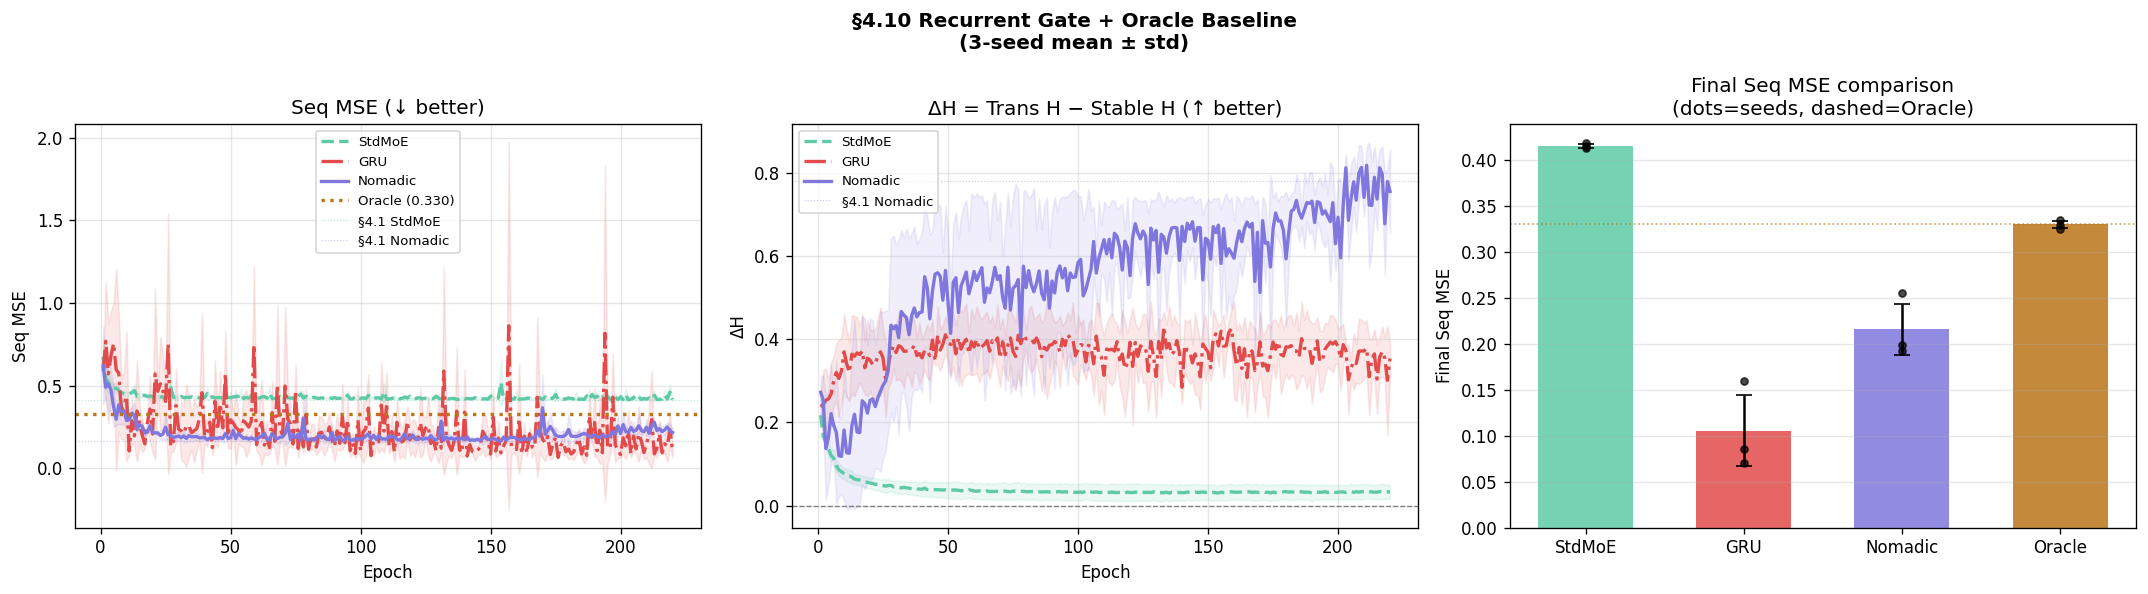

Figure saved.


In [10]:
COLORS={'StdMoE':'#5DCAA5','GRU':'#E24B4A','Nomadic':'#7F77DD','Oracle':'#BA7517'}
LS={'StdMoE':'--','GRU':'-.',  'Nomadic':'-',    'Oracle':':'}

fig,axes=plt.subplots(1,3,figsize=(18,5))
fig.suptitle('§4.10 Recurrent Gate + Oracle Baseline\n(3-seed mean ± std)',
             fontsize=12,fontweight='bold')

# Left: Seq MSE curves (StdMoE / GRU / Nomadic; Oracle는 final point만)
ax=axes[0]
for mn in ['StdMoE','GRU','Nomadic']:
    curves=np.array([all_results[mn][s]['mse_log'] for s in SEEDS])
    m=curves.mean(0); s=curves.std(0); ep=np.arange(1,len(m)+1)
    ax.plot(ep,m,color=COLORS[mn],ls=LS[mn],lw=2,label=mn)
    ax.fill_between(ep,m-s,m+s,color=COLORS[mn],alpha=0.12)
# Oracle: horizontal line (evaluation only, no training curve)
or_mean=np.mean([all_results['Oracle'][s]['mse_log'][-1] for s in SEEDS])
ax.axhline(or_mean,color=COLORS['Oracle'],ls=LS['Oracle'],lw=2,label=f'Oracle ({or_mean:.3f})')
ax.axhline(0.410,color='#5DCAA5',lw=0.7,ls=':',alpha=0.4,label='§4.1 StdMoE')
ax.axhline(0.165,color='#7F77DD',lw=0.7,ls=':',alpha=0.4,label='§4.1 Nomadic')
ax.set_xlabel('Epoch'); ax.set_ylabel('Seq MSE')
ax.set_title('Seq MSE (↓ better)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Middle: ΔH curves
ax2=axes[1]
for mn in ['StdMoE','GRU','Nomadic']:
    curves=np.array([[d['dh'] for d in all_results[mn][s]['dyn_log']] for s in SEEDS])
    m=np.nanmean(curves,0); s=np.nanstd(curves,0); ep=np.arange(1,len(m)+1)
    ax2.plot(ep,m,color=COLORS[mn],ls=LS[mn],lw=2,label=mn)
    ax2.fill_between(ep,m-s,m+s,color=COLORS[mn],alpha=0.12)
ax2.axhline(0,color='gray',lw=0.8,ls='--')
ax2.axhline(0.781,color='#7F77DD',lw=0.7,ls=':',alpha=0.4,label='§4.1 Nomadic')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('ΔH')
ax2.set_title('ΔH = Trans H − Stable H (↑ better)'); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# Right: final bar — Seq MSE 4-way comparison
ax3=axes[2]
models_bar=['StdMoE','GRU','Nomadic','Oracle']
mse_means=[np.mean([all_results[mn][s]['mse_log'][-1] for s in SEEDS]) for mn in models_bar]
mse_stds =[np.std( [all_results[mn][s]['mse_log'][-1] for s in SEEDS]) for mn in models_bar]
x=np.arange(len(models_bar))
bars=ax3.bar(x,mse_means,yerr=mse_stds,capsize=5,
             color=[COLORS[mn] for mn in models_bar],alpha=0.85,width=0.6)
for i,mn in enumerate(models_bar):
    for s in SEEDS:
        ax3.scatter(i,all_results[mn][s]['mse_log'][-1],color='black',s=18,zorder=5,alpha=0.7)
ax3.set_xticks(x); ax3.set_xticklabels(models_bar)
ax3.set_ylabel('Final Seq MSE')
ax3.set_title('Final Seq MSE comparison\n(dots=seeds, dashed=Oracle)')
ax3.axhline(or_mean,color=COLORS['Oracle'],lw=1.0,ls=':',alpha=0.7)
ax3.grid(axis='y',alpha=0.3)

plt.tight_layout()
plt.savefig('/content/recurrent_oracle_comparison.png',dpi=150,bbox_inches='tight')
plt.show()
print('Figure saved.')


In [12]:
import json, os, shutil
from google.colab import drive

drive.mount('/content/drive')

SAVE_DIR='/content/drive/MyDrive/recurrent_oracle_results'
os.makedirs(SAVE_DIR,exist_ok=True)
df.to_csv(os.path.join(SAVE_DIR,'results_summary.csv'),index=False)

detail_rows=[]
for mn in ['StdMoE','GRU','Nomadic','Oracle']:
    for seed in SEEDS:
        r=all_results[mn][seed]; d=r['dyn_log'][-1]
        detail_rows.append({
            'Model':mn,'Seed':seed,
            'Seq MSE':r['mse_log'][-1],
            'Stable H':d['sh'],'Trans H':d['th'],
            'ΔH':d['dh'],
            'Switch Lat':d.get('lat',float('nan')),
        })
df_d=pd.DataFrame(detail_rows)
df_d.to_csv(os.path.join(SAVE_DIR,'results_per_seed.csv'),index=False)
print(df_d.to_string(float_format=lambda x:f'{x:.4f}',index=False))

if os.path.exists('/content/recurrent_oracle_comparison.png'):
    shutil.copy('/content/recurrent_oracle_comparison.png',
                os.path.join(SAVE_DIR,'recurrent_oracle_comparison.png'))
print(f'\nSaved to: {SAVE_DIR}')
for f in sorted(os.listdir(SAVE_DIR)): print(f'  {f}')

Mounted at /content/drive
  Model  Seed  Seq MSE  Stable H  Trans H     ΔH  Switch Lat
 StdMoE    42   0.4179    0.9815   1.0143 0.0327         NaN
 StdMoE   123   0.4123    0.9307   0.9429 0.0122         NaN
 StdMoE   456   0.4152    1.0255   1.0789 0.0533         NaN
    GRU    42   0.1593    0.4039   0.7513 0.3474      1.8333
    GRU   123   0.0704    0.3536   0.7516 0.3980      2.0000
    GRU   456   0.0860    0.3382   0.6533 0.3151      3.0278
Nomadic    42   0.1923    0.2859   0.9086 0.6228      0.4722
Nomadic   123   0.1990    0.1575   0.9351 0.7776      3.1111
Nomadic   456   0.2550    0.0831   0.9482 0.8651      0.1111
 Oracle    42   0.3289    0.0000   0.0000 0.0000      0.0000
 Oracle   123   0.3252    0.0000   0.0000 0.0000      0.0000
 Oracle   456   0.3347    0.0000   0.0000 0.0000      0.0000

Saved to: /content/drive/MyDrive/recurrent_oracle_results
  recurrent_oracle_comparison.png
  results_per_seed.csv
  results_summary.csv
